# 1. 데이터 불러오기 및 전처리

- pandas로 데이터 셋 로드
- data info 확인
- date 기준으로 내림 차순 정렬 

In [1]:
#pandas로 데이터 셋 로드 

import pandas as pd 
from IPython.display import display

df = pd.read_csv('../../data/crawled_data.csv')
df.info()

# 시계열 분석하기 위해 date의 dtype을 datetime 형식으로 바꾸기 
df['date'] = pd.to_datetime(df['date'])

# date 기준으로 내림차순 정렬
df_sorted = df.sort_values(by='date', ascending=False)


# 최신 뉴스
print("최신 뉴스 5개")
display(df_sorted[['date', 'title']].head())

# 오래된 뉴스
print("오래된 뉴스 5개")
display(df_sorted[['date', 'title']].tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18558 entries, 0 to 18557
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   18558 non-null  object
 1   link    18558 non-null  object
 2   author  18558 non-null  object
 3   date    18558 non-null  object
 4   body    18558 non-null  object
dtypes: object(5)
memory usage: 725.1+ KB
최신 뉴스 5개


,date,title
0,2025-06-05,"허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시"
13,2025-06-05,AI빅데이터쇼 아크릴 AI 플랫폼으로 헬스케어 혁신
1,2025-06-05,"레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소"
23,2025-06-05,6월4일 기업 비용 절감을 위한 AI 활용의 새로운 사례...노후 소프트웨어 현대화
22,2025-06-05,AI의 역사 41 추론 중 결국 멈춰서 버린 로봇 프레임 문제와 다니엘 데닛


오래된 뉴스 5개


,date,title
18553,2020-01-02,"구글AI, 사람 의사보다 유방암 진단 정확도 높다"
18554,2020-01-02,2020년 AI혁명 우리의 삶이 완전히 바뀐다 AI타임스 신년시리즈
18555,2020-01-02,AI가 차량 소리 감지해 헤드폰에 경보 울린다
18556,2020-01-01,경자년 새해 맞이 보성 율포해변 불꽃축제
18557,2020-01-01,포토 케이스 Case IH의 자율주행 트랙터


## 📌 현재 수집한 뉴스 데이터는 2020-01-01~ 2025-06-05까지의 18558개의 데이터 
---

## 1) 제목, 날짜, 본문 컬럼만 남기기 

In [3]:
# 제목, 날짜, 본문 컬럼만 남기기 
df = df[['title','date','body']]
df.head()

,title,date,body
0,"허깅페이스, 맥북에서 구동하는 로봇용 시각언어행동 모델 출시",2025-06-05,허깅페이스가 범용 로봇 에이전트 개발을 위한 오픈소스 비전언어행동 VLA 모델을 선...
1,"레딧, 무단으로 AI 훈련 데이터 사용한 앤트로픽 고소",2025-06-05,소셜 미디어 플랫폼 레딧이 앤트로픽을 상대로 동의 없이 게시물을 수집해 인공지능 A...
2,"미스트랄, 코딩 AI 역량 총 집결한 기업용 어시스턴트 미스트랄 코드 출시",2025-06-05,미스트랄 AI가 기업을 위한 인공지능 AI 코딩 어시스턴트를 공개했다. 이번 출시는...
3,"오픈AI, 업무용 AI 도구 대거 출시...MS구글과 에이전트 경쟁 불가피",2025-06-05,오픈AI가 마이크로소프트 MS 나 구글의 기업용 인공지능 AI 제품을 겨냥한 업무용...
4,미중 갈등으로 애플 인텔리전스 중국 출시 지연,2025-06-05,알리바바와의 협력으로 중국에서 아이폰용 인공지능 AI 서비스를 출시하려는 애플의 계...


# 2. 형태소 분석 

### 1) 본문 데이터를 준비
### 2) 형태소 분석 → 불용어 제거 
    형태소 분석을 하다보니, 중요한 기술 키워드 인데 단어가 분리되는 현상이 있다. 예를 들어 '허깅 페이스' 가 '허', '깅', '페이스' 라고 인식된다. 
    이런 단어들을 병합 키워드 딕셔너리로 만들어 주는 작업을 진행했다.
- Word2Vec (Skip-gram) 학습 → 단어 임베딩 추출
- 유사도 분석, 시각화, 자동 키워드 확장 등에 활용 
---

### 📌 1) 본문 데이터 준비 

#### 2024년 1월 ~ 2025 5월 범위(17개월)로 뉴스를 필터링 한다. 
- 2025 6월 데이터는 데이터가 충분하지 않아 올바른 분석을 하지 못하므로 제외시켰다. 
- `df_filtered` :   2024년 1월 ~ 2025 5월로 필터링된 데이터 

In [6]:
# 날짜 컬럼이 문자열이라면 datetime으로 변환
df['date'] = pd.to_datetime(df['date'])

# 2025년 1월 ~ 6월 범위 필터링
start_date = '2024-01-01'
end_date = '2025-05-31'

df_filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

#### 뉴스 본문 추출 `body_texts`

In [7]:
body_texts = df_filtered['body']

### 📌 2) 형태소 분석 

In [8]:
# 형태소 분석 
import sys
sys.path.append('../../') # 상위 폴더 접근 허용 

from analysis.preprocess_module import preprocess_text, remove_stopwords

#형태소 분석 적용 
body_tokens = body_texts.apply(preprocess_text)

#불용어 정의 
stopwords = set([
    "의", "이", "가", "은", "는", "을", "를", "에", "에서", "도", "로", "으로", "있", "들", "그", "되",
    "한", "하다", "되다", "및", "이다", "그리고", "하지만", "또한", "수", "것", "등", "같", 
])

#불용어 제거 
filtered_body_tokens = body_tokens.apply(lambda tokens: remove_stopwords(tokens, stopwords))

                                           
for i in range(5):  
    print(f"\n🔹 [{i+1}번째]")
    print("불용어 제거 전:", body_tokens.iloc[i][:20])   # 너무 길 경우 앞 20개만 표시
    print("불용어 제거 후:", filtered_body_tokens.iloc[i][:20])
    print("-" * 50)


🔹 [1번째]
⛔ 불용어 제거 전: ['일', '론', '머스크', 'ceo', '가', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '을', '포함', '한', '약물', '을', '다량', '복용', '했다는']
✅ 불용어 제거 후: ['일', '론', '머스크', 'ceo', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '포함', '약물', '다량', '복용', '했다는', '주장', '뉴욕', '타임스', 'nyt']
--------------------------------------------------

🔹 [2번째]
⛔ 불용어 제거 전: ['구글', '의', '검색', '독점', '해소', '안', '을', '결정', '할', '미국', '재판', '에서', '판사', '가', '인공', '지능', 'ai', '이', '검색', '의']
✅ 불용어 제거 후: ['구글', '검색', '독점', '해소', '안', '결정', '할', '미국', '재판', '판사', '인공', '지능', 'ai', '검색', '경쟁', '기술', '인지', '대해', '의문', '가지']
--------------------------------------------------

🔹 [3번째]
⛔ 불용어 제거 전: ['바이브', '코딩', '이', '인기', '를', '끄는', '가운데', '인공', '지능', 'ai', '이', '생', '성', '한', '코드', '가', '작동', '하지', '않거나', '보안']
✅ 불용어 제거 후: ['바이브', '코딩', '인기', '끄는', '가운데', '인공', '지능', 'ai', '생', '성', '코드', '작동', '하지', '않거나', '보안', '문제', '일으킬', '있다는', '지적', '나왔다']
--------------------------------------------------

🔹 [4번째]
⛔ 불용어 제거 전: ['대형', '언어

In [11]:
#키워드 병합 함수 
def merge_keywords(tokens, merge_dict):
    merged = [] #병합된 결과를 반환할 리스트 
    i = 0 # 토큰 리스트의 현재 위치 인덱스 
    while i < len(tokens):
        found = False
        for length in [3, 2]:  # 3단어 조합 우선 → 2단어 조합
            group = tuple(tokens[i:i+length])
            if group in merge_dict:
                merged.append(merge_dict[group])
                i += length
                found = True
                break
        if not found:
            merged.append(tokens[i])
            i += 1
    return merged


# 병합 딕셔너리 정의
merge_dict = {
    ('인공', '지능'): '인공지능',
    ('오픈', 'ai'): '오픈ai',
    ('생', '성'): '생성',
    ('허', '깅', '페이스'): '허깅페이스',
    ('챗', 'gpt'): '챗gpt',
    ('chat', 'gpt'): '챗gpt',
    ('양자', '컴퓨터'): '양자컴퓨팅',
    ('양자', '컴퓨팅'): '양자컴퓨팅',
    ('자연어', '처리'): 'nlp',
    ('이미지', '처리'): '이미지처리',
    ('대형','언어', '모델'): '대형언어모델',
    ('바이브','코딩'): '바이브코딩'
}


# 병합 함수 적용
merged_tokens = filtered_body_tokens.apply(lambda tokens: merge_keywords(tokens, merge_dict))


In [12]:
# 병합 결과 확인
for i in range(5):
    print(f"\n🔹 [{i+1}번째 뉴스]")
    print("병합 전:", filtered_body_tokens.iloc[i])
    print("병합 후:", merged_tokens.iloc[i])
    print("-" * 50)



🔹 [1번째 뉴스]
병합 전: ['일', '론', '머스크', 'ceo', '지난해', '대선', '선거', '운동', '기간', '중', '마약', '포함', '약물', '다량', '복용', '했다는', '주장', '뉴욕', '타임스', 'nyt', '내놓았다', '대해', '머스크', 'ceo', '허위', '보도', '신문사', '라고', '비난', '했다', 'nyt', '30일', '현지', '시간', '소식통', '인용', '머스크', 'ceo', '지난해', '도널드', '트럼프', '대통령', '선거', '유세', '지원', '하는', '도중', '엑스터시', '와', '혼각', '버섯', '포함', '약물', '다량', '복용', '했으며', '이로', '인한', '부작용', '주변', '사람', '에게', '털어', '놓았다고', '보도', '했다', '머스크', 'ceo', '잘', '아는', '사람', '따르면', '각성제', '인', '애더럴', '포함', '해', '알약', '20', '개', '든', '상자', '가지', '고', '다녔으며', '약물', '사용', '일상', '적', '인', '수준', '넘었다고', '전', '했다', '특히', '케타민', '과도', '하게', '복용', '해', '방광', '문제', '생긴다고', '주변', '알렸다는', '백악관', '합류', '이후', '약물', '계속', '복용', '했는지는', '불분명', '하다고', '전', '했다', '내각', '구성원', '비난', '하고', '행사', '에서는', '나치', '식', '경례', '물의', '일으키는', '불안정한', '행동', '이어', '갔다', '이전', '에도', '약물', '손', '댔다는', '이야기', '소개', '했다', '소셜', '미디어', '통해', '엄청난', '행복감', '과', '끔찍한', '침체', '끊임없는', '스트레스', '느꼈다라고', '말', '했다', '또', '전통', '적', '인', '치료

# 3. 키워드 분석

In [16]:
from collections import Counter

# 평탄화
merged_body_keywords = [token for tokens in merged_tokens for token in tokens]

# 빈도 계산
keyword_counts = Counter(merged_body_keywords)
top_keywords = keyword_counts.most_common(50)

# 상위 30개 출력
for rank, (word, count) in enumerate(top_keywords, ):
    print(f"{rank:2}. {word:<10} : {count}회")


 0. ai         : 59735회
 1. 했다         : 41099회
 2. 할          : 29659회
 3. 하는         : 26437회
 4. 과          : 24644회
 5. 적          : 24250회
 6. 와          : 22685회
 7. 모델         : 18361회
 8. 인          : 17439회
 9. 하고         : 16595회
10. 기술         : 16563회
11. 있다         : 15973회
12. 해          : 15469회
13. 데이터        : 13350회
14. 다          : 13149회
15. 기업         : 12569회
16. 통해         : 11778회
17. 개발         : 10834회
18. 밝혔다        : 10611회
19. 말          : 10524회
20. 된          : 10294회
21. 대표         : 10042회
22. 서비스        : 9848회
23. 전          : 9680회
24. 사용         : 8761회
25. 있는         : 8655회
26. 생성         : 8601회
27. 에는         : 8496회
28. 오픈ai       : 8357회
29. 이라고        : 8140회
30. 제공         : 8044회
31. 위          : 7991회
32. 또          : 7985회
33. 활용         : 7840회
34. 인공지능       : 7745회
35. 기반         : 7570회
36. 이번         : 7429회
37. 기능         : 7284회
38. 사용자        : 7098회
39. 출시         : 6890회
40. 위해         : 6865회
41. 설명         : 6758회
42. 고       

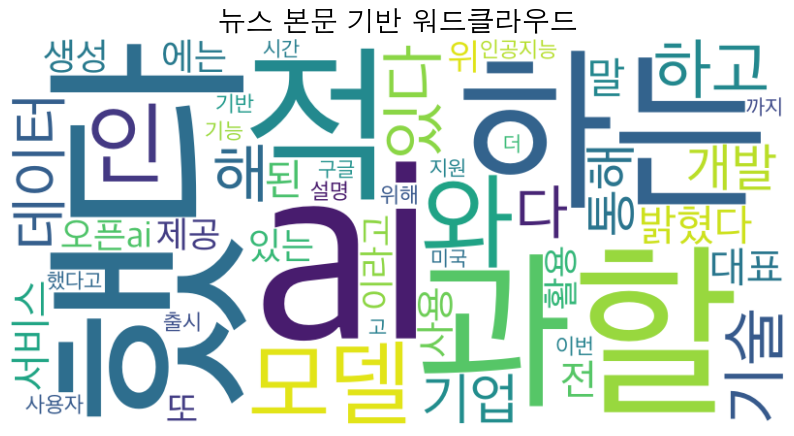

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import platform
##############
from collections import Counter
import matplotlib.font_manager as fm

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS인 경우
# plt.rcParams['font.family'] = 'NanumGothic'  # 설치했을 때
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

############

if platform.system() == 'Windows':
    font_path = 'NanumFothic.ttf'
elif platform.system() == 'Darwin': #macOS
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else: #Assume Colab or Linux
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    
# 워드클라우드 생성
wc = WordCloud(
   font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(dict(top_keywords))

# 3. 시각화
plt.figure(figsize=(10,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("뉴스 본문 기반 워드클라우드", fontsize=20)
plt.show()


# 클러스터링 

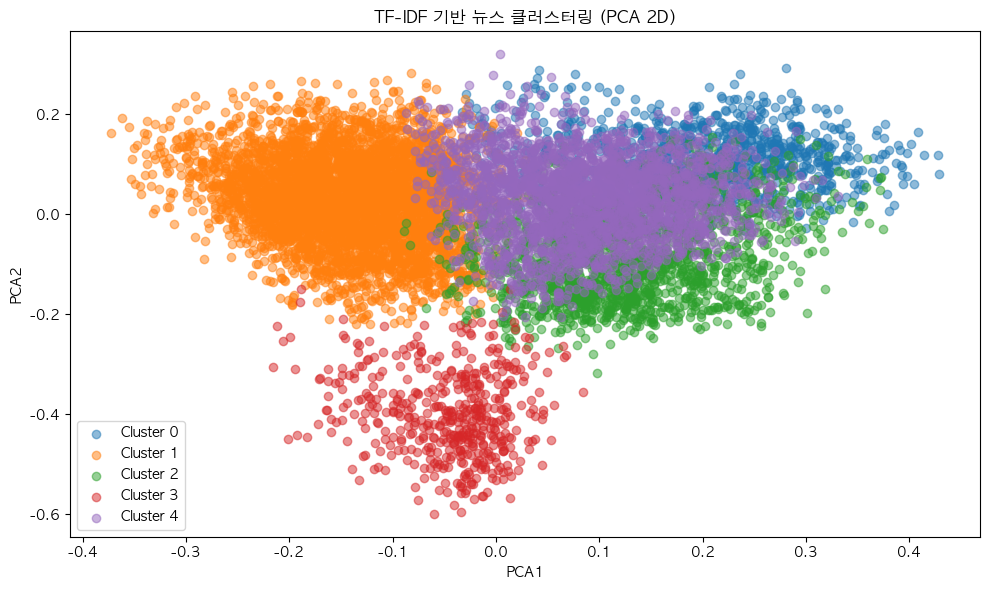

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. TF-IDF 벡터화
corpus = [' '.join(tokens) for tokens in merged_tokens]
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

# 2. KMeans 클러스터링
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# 3. 클러스터별 상위 키워드 추출
top_keywords_per_cluster = []
for i in range(n_clusters):
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[::-1][:10]
    top_keywords = [feature_names[idx] for idx in top_indices]
    top_keywords_per_cluster.append(top_keywords)

# 4. 결과 데이터프레임 생성
df_result = df_filtered.copy().reset_index(drop=True)
df_result["cluster"] = labels

# 5. 차원 축소 (PCA) 및 시각화
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

df_result["pca1"] = X_reduced[:, 0]
df_result["pca2"] = X_reduced[:, 1]

# 시각화
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    cluster_data = df_result[df_result["cluster"] == i]
    plt.scatter(cluster_data["pca1"], cluster_data["pca2"], label=f"Cluster {i}", alpha=0.5)

plt.title("TF-IDF 기반 뉴스 클러스터링 (PCA 2D)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.tight_layout()
plt.show()




In [22]:
# 클러스터 중심 키워드 추출
top_keywords_per_cluster = []

for i in range(n_clusters):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:10]
    keywords = [feature_names[idx] for idx in top_indices]
    top_keywords_per_cluster.append(keywords)

# 보기 좋게 출력
for i, keywords in enumerate(top_keywords_per_cluster):
    print(f"\n{i}. Cluster {i} 주요 키워드:")
    print(" + ".join(keywords))



0. Cluster 0 주요 키워드:
모델 + 했다 + 추론 + 성능 + ai + llm + 하는 + 데이터 + 오픈 + 소스

1. Cluster 1 주요 키워드:
ai + 대표 + 기술 + 했다 + 솔루션 + 서비스 + 기업 + 데이터 + 사업 + 하는

2. Cluster 2 주요 키워드:
오픈ai + ai + ceo + 했다 + 중국 + 입니다 + 투자 + 미국 + 엔비디아 + 머스크

3. Cluster 3 주요 키워드:
태양광 + 에너지 + 전력 + 재생 + 설치 + 발전 + 발전소 + 풍력 + 했다 + gw

4. Cluster 4 주요 키워드:
ai + 했다 + 사용자 + 하는 + 기능 + 생성 + 구글 + 있다 + 사용 + 이미지


| 클러스터      | 중심 키워드     | 산업 방향성                |
| --------- | ---------- | --------------------- |
| Cluster 0 | 모델 성능 + 추론 | **LLM 성능 비교, 모델 최적화** |
| Cluster 1 | 기업 솔루션     | **AI 솔루션 비즈니스화**      |
| Cluster 2 | 글로벌 기업/정책  | **AI 생태계 전략 경쟁**      |
| Cluster 3 | 에너지 산업     | **AI + ESG + 재생에너지**  |
| Cluster 4 | 생성형 UX     | **개인화 중심 생성형 AI 서비스** |


/var/folders/5h/9d1tm36x78vg7z4pjs8gzzv00000gn/T/ipykernel_51076/3292102876.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


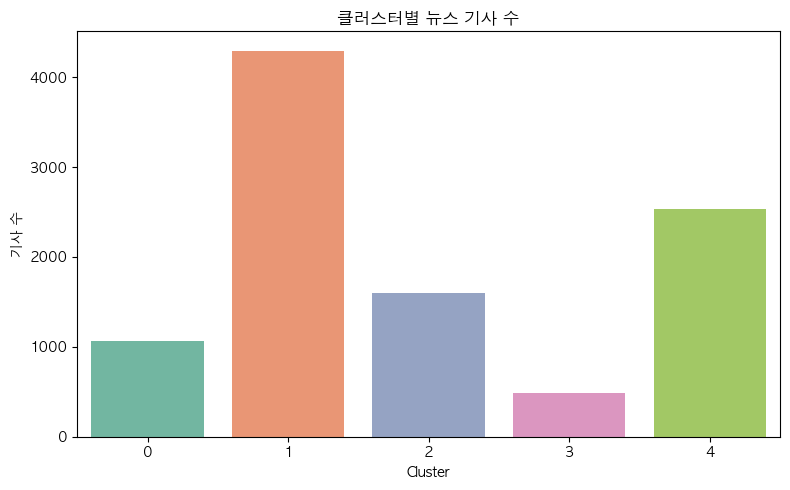

In [23]:
# 클러스터별 뉴스 수 비율 분석

import seaborn as sns
import matplotlib.pyplot as plt

# 클러스터 결과 복원
df_result = df_filtered.copy().reset_index(drop=True)
df_result["cluster"] = labels
df_result["pca1"] = X_reduced[:, 0]
df_result["pca2"] = X_reduced[:, 1]

# 클러스터별 뉴스 수 비율 계산
cluster_counts = df_result["cluster"].value_counts().sort_index()
cluster_percent = cluster_counts / cluster_counts.sum() * 100

# 막대그래프 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.title("클러스터별 뉴스 기사 수")
plt.xlabel("Cluster")
plt.ylabel("기사 수")
plt.tight_layout()
plt.show()


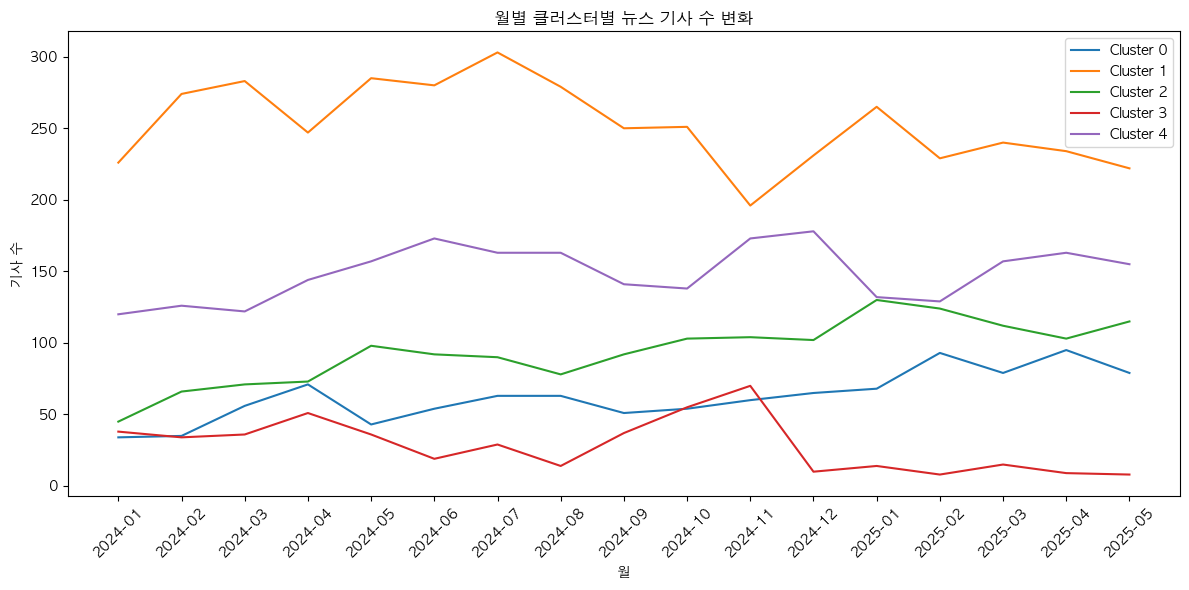

In [24]:
# 날짜 정보와 클러스터 ID를 기반으로 월별 뉴스 수 집계
df_result["date"] = pd.to_datetime(df_result["date"])
df_result["month"] = df_result["date"].dt.to_period("M")
df_cluster_month = df_result.groupby(["month", "cluster"]).size().reset_index(name="count")

# 클러스터별 월별 추이 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for cluster_id in sorted(df_cluster_month["cluster"].unique()):
    data = df_cluster_month[df_cluster_month["cluster"] == cluster_id]
    plt.plot(data["month"].astype(str), data["count"], label=f"Cluster {cluster_id}")

plt.title("월별 클러스터별 뉴스 기사 수 변화")
plt.xlabel("월")
plt.ylabel("기사 수")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## cluster1의 상위 키워드 추출 및 확인

In [ ]:
# 인덱스 재정렬 
merged_tokens = merged_tokens.reset_index(drop=True)
df_result = df_result.reset_index(drop=True)

# Cluster 1 문서 추출
cluster_1_docs = df_result[df_result["cluster"] == 1]

# 토큰 병합
corpus_1 = [' '.join(merged_tokens[i]) for i in cluster_1_docs.index]


# TF-IDF 기반 핵심 키워드 추출
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=1000)
X = vectorizer.fit_transform(corpus_1)
feature_names = vectorizer.get_feature_names_out()
avg_tfidf = X.mean(axis=0).A1

# 결과 정리
import pandas as pd
df_keywords = pd.DataFrame({
    "keyword": feature_names,
    "avg_tfidf": avg_tfidf
}).sort_values(by="avg_tfidf", ascending=False)

# 상위 30개 키워드 출력
df_keywords.head(30)


,keyword,avg_tfidf
49,ai,0.130233
199,기술,0.053051
255,데이터,0.045551
443,서비스,0.042837
242,대표,0.042741
200,기업,0.042464
924,하는,0.041619
476,솔루션,0.037341
921,하고,0.034407
103,개발,0.033011


# TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석하기 

In [33]:
from gensim.models import Word2Vec

# 1. Cluster 1 문서에 포함된 토큰 리스트만 추출
cluster_1_tokens = [merged_tokens[i] for i in cluster_1_docs.index]

# 2. Word2Vec 모델 학습
w2v_model = Word2Vec(
    sentences=cluster_1_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,  # skip-gram
    seed=42
)

# 3. 상위 TF-IDF 키워드 중 일부 키워드의 유사 단어 보기
# 예시 키워드 선택 (TF-IDF 상위)
sample_keywords = df_keywords.head(10)["keyword"].tolist()
similar_words_dict = {}

for keyword in sample_keywords:
    if keyword in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(keyword, topn=10)
        similar_words_dict[keyword] = similar_words

# 결과 보기
import pandas as pd

# 키워드별 유사 단어 DataFrame으로 정리
similar_words_flat = []
for key, values in similar_words_dict.items():
    for word, score in values:
        similar_words_flat.append({"base_keyword": key, "similar_word": word, "similarity": score})

df_similar = pd.DataFrame(similar_words_flat)



In [34]:
print("📌 TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석\n")

for keyword, similar_list in similar_words_dict.items():
    print(f"🔹 '{keyword}' 와 의미상 유사한 단어 Top 10:")
    for word, score in similar_list:
        print(f"   - {word} ({score:.4f})")
    print()

📌 TF-IDF 상위 키워드 기반 Word2Vec 유사 단어 분석

🔹 'ai' 와 의미상 유사한 단어 Top 10:
   - dap (0.6621)
   - 미들웨어 (0.6504)
   - ixigen (0.6503)
   - 블레스 (0.6498)
   - sllm (0.6491)
   - llmops (0.6478)
   - loop (0.6474)
   - al (0.6463)
   - 망라 (0.6409)
   - 박석준 (0.6390)

🔹 '기술' 와 의미상 유사한 단어 Top 10:
   - 겸비 (0.6718)
   - 양자컴퓨터 (0.6675)
   - 원천 (0.6624)
   - 합하면 (0.6602)
   - 국수 (0.6586)
   - 벤치마킹 (0.6507)
   - 다시금 (0.6503)
   - lng (0.6475)
   - 무장 (0.6465)
   - 성공사례 (0.6464)

🔹 '데이터' 와 의미상 유사한 단어 Top 10:
   - 수집 (0.7191)
   - 가공 (0.6895)
   - 라벨 (0.6844)
   - 정제 (0.6679)
   - 링 (0.6547)
   - 위성영상 (0.6512)
   - 말뭉치 (0.6455)
   - 병렬 (0.6441)
   - 산재 (0.6427)
   - 셋 (0.6377)

🔹 '서비스' 와 의미상 유사한 단어 Top 10:
   - 구독 (0.6738)
   - 멘탈 (0.6662)
   - 헬프 (0.6603)
   - 젠투 (0.6591)
   - 랜딩존 (0.6532)
   - 솔루션 (0.6508)
   - 핏 (0.6503)
   - paas (0.6498)
   - api (0.6443)
   - 응용프로그램 (0.6373)

🔹 '대표' 와 의미상 유사한 단어 Top 10:
   - 전문 (0.6664)
   - 신년사 (0.6411)
   - 자회사 (0.6231)
   - 변성준 (0.6137)
   - cto (0.6081)
   - 김영 (0.

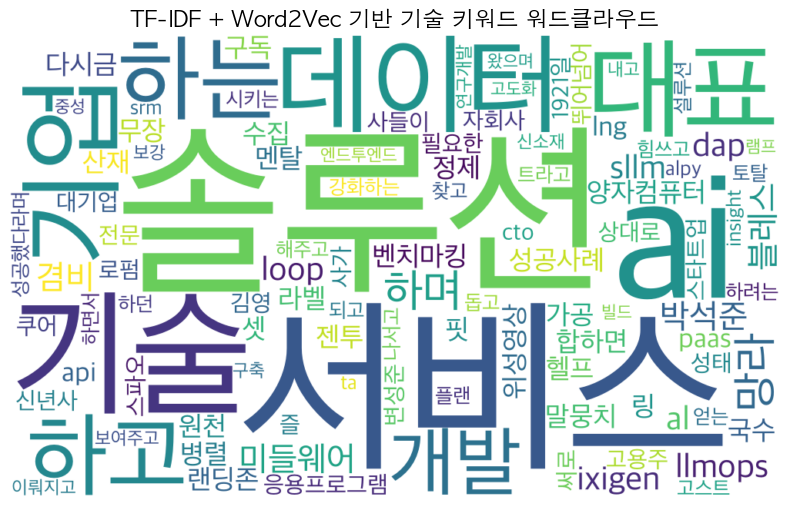

In [41]:
# 1. 모든 유사 단어 결과를 평탄화하여 DataFrame 생성
similar_words_flat = []
for base_keyword, similar_list in similar_words_dict.items():
    for word, score in similar_list:
        similar_words_flat.append({
            "base_keyword": base_keyword,
            "similar_word": word,
            "similarity": score
        })

df_word2vec_mapped = pd.DataFrame(similar_words_flat)


# 모든 키워드를 평탄화 (base + similar)
words = df_word2vec_mapped["base_keyword"].tolist() + df_word2vec_mapped["similar_word"].tolist()
word_freq = Counter(words)

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    background_color="white",
    width=1000,
    height=600
).generate_from_frequencies(word_freq)


# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF + Word2Vec 기반 기술 키워드 워드클라우드", fontsize=16)
plt.show()


In [42]:
# ces 기술 키워드 기반 활용할 방법이 있을까...? 흠...
# ces_keyword_dict = {
#     "AI": ["ai", "인공지능", "agentic ai", "on-device ai", "edge ai"],
#     "Generative AI": ["generative ai", "생성형 ai", "생성형 인공지능", "llm", "대규모 언어 모델", "대규모언어모델", "chatgpt", "챗gpt", "오픈ai", "openai"],
#     "Smart Home": ["스마트홈", "smart home", "홈ai", "home ai", "iot", "스마트 가전", "smart appliances", "스마트링", "smart ring"],
#     "Mobility": ["모빌리티", "mobility", "자율주행", "autonomous vehicle", "evtol", "전기차", "ev", "스마트 모빌리티"],
#     "XR": ["xr", "ar", "vr", "ar/vr", "확장현실", "가상현실", "증강현실", "spatial computing", "스마트글래스", "smart glasses", "스마트 안경"],
#     "Digital Health": ["디지털 헬스케어", "digital health", "remote monitoring", "at-home diagnostics", "스마트 헬스케어", "헬스케어 ai"],
#     "Robotics": ["로봇", "로보틱스", "robotics", "개인용 로봇", "companion robot", "서비스 로봇", "농업 로봇"],
#     "Quantum Computing": ["양자컴퓨터", "quantum computing", "퀀텀 컴퓨팅"],
#     "ESG / Energy": ["esg", "지속가능성", "sustainability", "green tech", "친환경", "renewable energy", "에너지 전환", "energy transition", "off-grid"],
#     "Computing": ["ai chips", "ai 반도체", "ai 칩", "컴퓨팅 파워", "computing power", "edge computing", "온디바이스 ai"],
#     "Space Tech": ["우주기술", "스페이스 테크", "space tech", "aerotech", "우주 탐사", "evtol"],
#     "Food Tech": ["푸드테크", "food tech", "agritech", "농업 기술"]
# }
